In [1]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
import matplotlib.pyplot as plt
import os

In [2]:
def bandpass(sig, lowcut, highcut, fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, sig)

def notch_filter(sig, freq, fs, q=30):
    b, a = iirnotch(freq / (fs/2), q)
    return filtfilt(b, a, sig)

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def clean_ecg(sig, fs=125):
    sig = bandpass(sig, 0.5, 40, fs)
    sig = notch_filter(sig, 50, fs)
    return normalize(sig)

def clean_ppg(sig, fs=125):
    sig = bandpass(sig, 0.5, 8, fs)
    return normalize(sig)

print("Filters defined")

Filters defined


In [3]:
def extract_paired_beats(ecg_raw, ppg_raw, fs=125, window=187):
    ecg = clean_ecg(ecg_raw, fs)
    ppg = clean_ppg(ppg_raw, fs)

    # Adaptive threshold: use 60% of the signal's max amplitude
    # This adapts to each patient's signal strength
    adaptive_height = 0.6 * ecg.max()

    peaks, _ = find_peaks(
        ecg,
        distance=int(0.5*fs),      # min 0.5s between beats
        height=adaptive_height,     # adaptive per recording
        prominence=0.3              # peak must stand out from surroundings
    )

    ecg_beats, ppg_beats = [], []
    half = window // 2

    for p in peaks:
        if p - half < 0 or p + half + 1 > len(ecg):
            continue

        beat_ecg = ecg[p-half : p+half+1]
        beat_ppg = ppg[p-half : p+half+1]

        # Quality check: R-peak must be near center of window (sample 80–110)
        if np.argmax(beat_ecg) < 75 or np.argmax(beat_ecg) > 115:
            continue

        ecg_beats.append(beat_ecg)
        ppg_beats.append(beat_ppg)

    return np.array(ecg_beats), np.array(ppg_beats)

print("Beat extractor defined")

Beat extractor defined


In [4]:
all_ecg, all_ppg = [], []
skipped = []

for i in range(1, 54):
    rec_id = f'data/bidmc/bidmc{i:02d}'
    try:
        r = wfdb.rdrecord(rec_id)
        # ECG = channel 4 (II lead), PPG = channel 1 (PLETH)
        ecg_raw = r.p_signal[:, 4]
        ppg_raw = r.p_signal[:, 1]

        # Skip if NaNs
        if np.isnan(ecg_raw).any() or np.isnan(ppg_raw).any():
            skipped.append(i)
            continue

        ecg_b, ppg_b = extract_paired_beats(ecg_raw, ppg_raw, fs=r.fs)

        if len(ecg_b) == 0:
            skipped.append(i)
            continue

        all_ecg.append(ecg_b)
        all_ppg.append(ppg_b)
        print(f"  bidmc{i:02d}: {len(ecg_b)} beat pairs")

    except Exception as e:
        skipped.append(i)
        print(f"  bidmc{i:02d}: SKIPPED — {e}")

print(f"\nSkipped: {skipped}")

  bidmc01: 238 beat pairs
  bidmc02: 4 beat pairs
  bidmc03: 587 beat pairs
  bidmc04: 19 beat pairs
  bidmc05: 202 beat pairs
  bidmc06: 219 beat pairs
  bidmc07: 267 beat pairs
  bidmc08: 312 beat pairs
  bidmc09: 608 beat pairs
  bidmc10: 276 beat pairs
  bidmc11: 233 beat pairs
  bidmc12: 210 beat pairs
  bidmc13: 532 beat pairs
  bidmc14: 281 beat pairs
  bidmc15: 221 beat pairs
  bidmc16: 4 beat pairs
  bidmc17: 416 beat pairs
  bidmc18: 223 beat pairs
  bidmc19: 348 beat pairs
  bidmc20: 235 beat pairs
  bidmc21: 319 beat pairs
  bidmc22: 357 beat pairs
  bidmc23: 5 beat pairs
  bidmc24: 271 beat pairs
  bidmc25: 310 beat pairs
  bidmc26: 187 beat pairs
  bidmc27: 231 beat pairs
  bidmc28: 317 beat pairs
  bidmc29: 270 beat pairs
  bidmc30: 269 beat pairs
  bidmc31: 190 beat pairs
  bidmc32: 26 beat pairs
  bidmc33: 293 beat pairs
  bidmc34: 324 beat pairs
  bidmc35: 286 beat pairs
  bidmc36: 581 beat pairs
  bidmc37: 239 beat pairs
  bidmc38: 322 beat pairs
  bidmc39: 474 beat 

In [5]:
ECG_pairs = np.concatenate(all_ecg, axis=0).reshape(-1, 187, 1).astype(np.float32)
PPG_pairs = np.concatenate(all_ppg, axis=0).reshape(-1, 187, 1).astype(np.float32)

print(f"Total paired beats : {ECG_pairs.shape[0]}")
print(f"ECG pairs shape    : {ECG_pairs.shape}")
print(f"PPG pairs shape    : {PPG_pairs.shape}")
print(f"ECG value range    : {ECG_pairs.min():.3f} – {ECG_pairs.max():.3f}")
print(f"PPG value range    : {PPG_pairs.min():.3f} – {PPG_pairs.max():.3f}")

Total paired beats : 14273
ECG pairs shape    : (14273, 187, 1)
PPG pairs shape    : (14273, 187, 1)
ECG value range    : 0.000 – 1.000
PPG value range    : 0.000 – 1.000


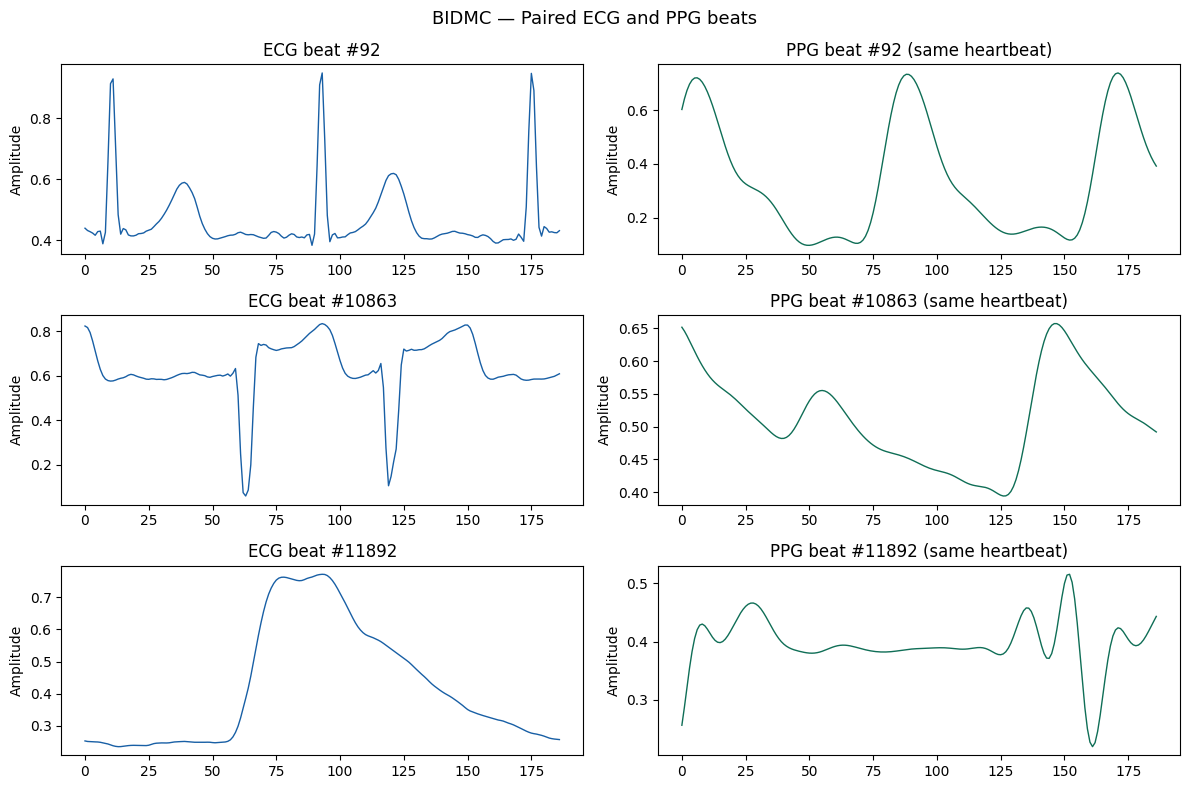

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for i in range(3):
    idx = np.random.randint(0, len(ECG_pairs))
    axes[i, 0].plot(ECG_pairs[idx].squeeze(), color='#185FA5', linewidth=1)
    axes[i, 0].set_title(f'ECG beat #{idx}')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 1].plot(PPG_pairs[idx].squeeze(), color='#0F6E56', linewidth=1)
    axes[i, 1].set_title(f'PPG beat #{idx} (same heartbeat)')
    axes[i, 1].set_ylabel('Amplitude')
plt.suptitle('BIDMC — Paired ECG and PPG beats', fontsize=13)
plt.tight_layout()
plt.savefig('data/bidmc_paired_beats.png', dpi=150)
plt.show()

In [7]:
np.save('data/ECG_pairs.npy', ECG_pairs)
np.save('data/PPG_pairs.npy', PPG_pairs)
print("Saved:")
print(f"   data/ECG_pairs.npy — {ECG_pairs.nbytes/1024/1024:.1f} MB")
print(f"   data/PPG_pairs.npy — {PPG_pairs.nbytes/1024/1024:.1f} MB")

Saved:
   data/ECG_pairs.npy — 10.2 MB
   data/PPG_pairs.npy — 10.2 MB


Well-centered beats (peak near sample 93): 14273/14273 (100.0%)
Potentially misaligned beats: 0 (0.0%)


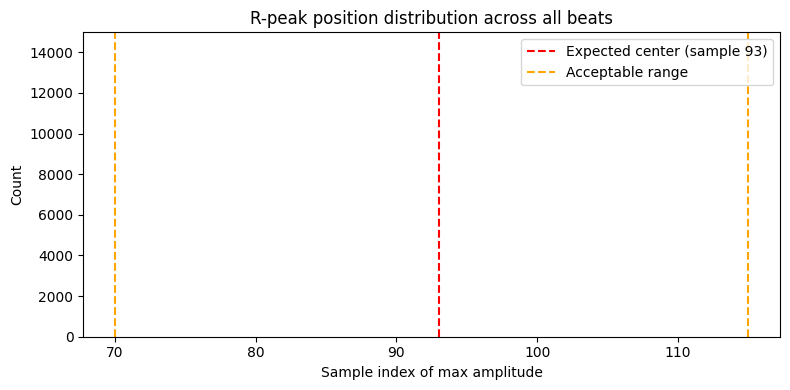

In [8]:
# Check R-peak detection quality
# A good beat has its max amplitude (R-peak) near the center (sample ~93)
# A bad beat has its max somewhere random

peak_positions = [np.argmax(ECG_pairs[i].squeeze()) for i in range(len(ECG_pairs))]
peak_positions = np.array(peak_positions)

centered = np.sum((peak_positions >= 70) & (peak_positions <= 115))
total = len(peak_positions)

print(f"Well-centered beats (peak near sample 93): {centered}/{total} ({100*centered/total:.1f}%)")
print(f"Potentially misaligned beats: {total - centered} ({100*(total-centered)/total:.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(peak_positions, bins=50, color='#185FA5', edgecolor='white')
plt.axvline(x=93, color='red', linestyle='--', label='Expected center (sample 93)')
plt.axvline(x=70, color='orange', linestyle='--', label='Acceptable range')
plt.axvline(x=115, color='orange', linestyle='--')
plt.title('R-peak position distribution across all beats')
plt.xlabel('Sample index of max amplitude')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

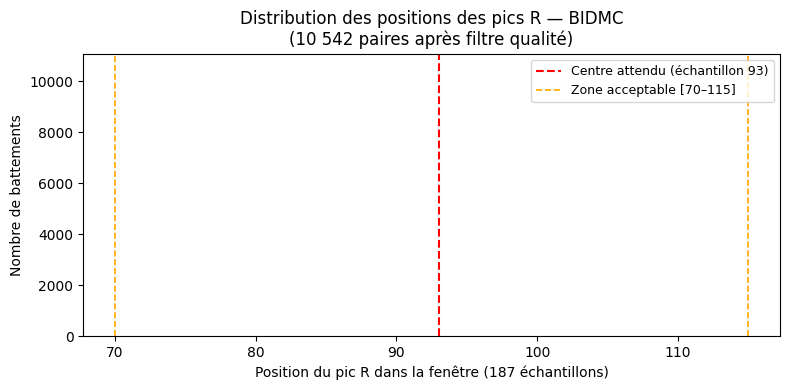

Saved.


In [16]:
peak_positions = np.array([np.argmax(ECG_clean[i].squeeze()) 
                            for i in range(len(ECG_clean))])

plt.figure(figsize=(8, 4))
plt.hist(peak_positions, bins=50, color='#185FA5', edgecolor='white')
plt.axvline(x=93, color='red', linestyle='--', linewidth=1.5, 
            label='Centre attendu (échantillon 93)')
plt.axvline(x=70, color='orange', linestyle='--', linewidth=1.2, 
            label='Zone acceptable [70–115]')
plt.axvline(x=115, color='orange', linestyle='--', linewidth=1.2)
plt.title('Distribution des positions des pics R — BIDMC\n(10 542 paires après filtre qualité)')
plt.xlabel('Position du pic R dans la fenêtre (187 échantillons)')
plt.ylabel('Nombre de battements')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/bidmc_rpeak_distribution.png', dpi=150)
plt.show()
print("Saved.")

In [9]:
def is_good_beat(ecg_beat, ppg_beat):
    ecg = ecg_beat.squeeze()
    ppg = ppg_beat.squeeze()

    # 1. R-peak must be centered between samples 75–115
    r_pos = np.argmax(ecg)
    if r_pos < 75 or r_pos > 115:
        return False

    # 2. R-peak must stand above mean (relaxed from 2std to 1std)
    if ecg[r_pos] < ecg.mean() + 1.0 * ecg.std():
        return False

    # 3. PPG must have at least 1 peak and no more than 4
    ppg_peaks, _ = find_peaks(ppg, height=ppg.mean(), distance=20)
    if len(ppg_peaks) == 0 or len(ppg_peaks) > 4:
        return False

    # 4. Signal must not be flat
    if ecg.std() < 0.03 or ppg.std() < 0.01:
        return False

    return True

# Apply filter
mask = np.array([is_good_beat(ECG_pairs[i], PPG_pairs[i])
                 for i in range(len(ECG_pairs))])

ECG_clean = ECG_pairs[mask]
PPG_clean = PPG_pairs[mask]

print(f"Before : {len(ECG_pairs)}")
print(f"After  : {len(ECG_clean)}")
print(f"Removed: {len(ECG_pairs) - len(ECG_clean)} ({100*(1-mask.mean()):.1f}%)")

Before : 14273
After  : 10542
Removed: 3731 (26.1%)


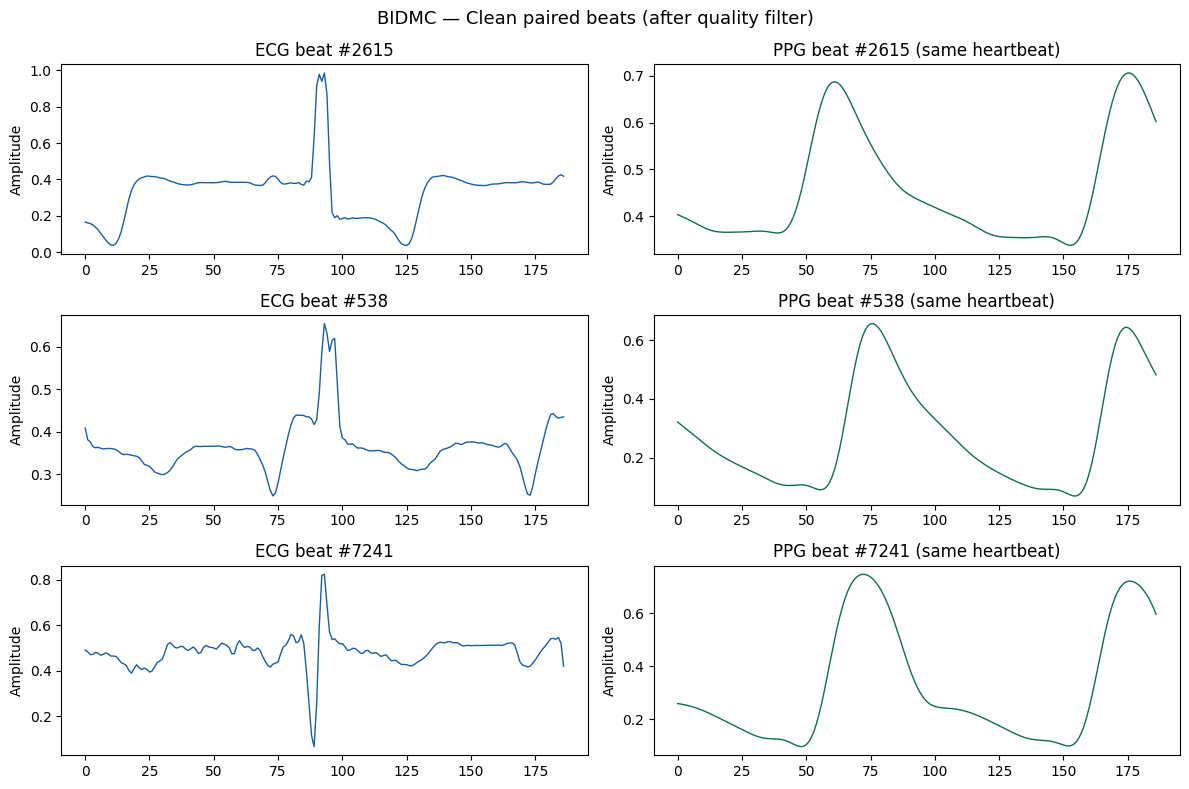

In [10]:
# Plot 3 random beats from the CLEAN set
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for i in range(3):
    idx = np.random.randint(0, len(ECG_clean))
    axes[i, 0].plot(ECG_clean[idx].squeeze(), color='#185FA5', linewidth=1)
    axes[i, 0].set_title(f'ECG beat #{idx}')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 1].plot(PPG_clean[idx].squeeze(), color='#0F6E56', linewidth=1)
    axes[i, 1].set_title(f'PPG beat #{idx} (same heartbeat)')
    axes[i, 1].set_ylabel('Amplitude')

plt.suptitle('BIDMC — Clean paired beats (after quality filter)', fontsize=13)
plt.tight_layout()
plt.show()

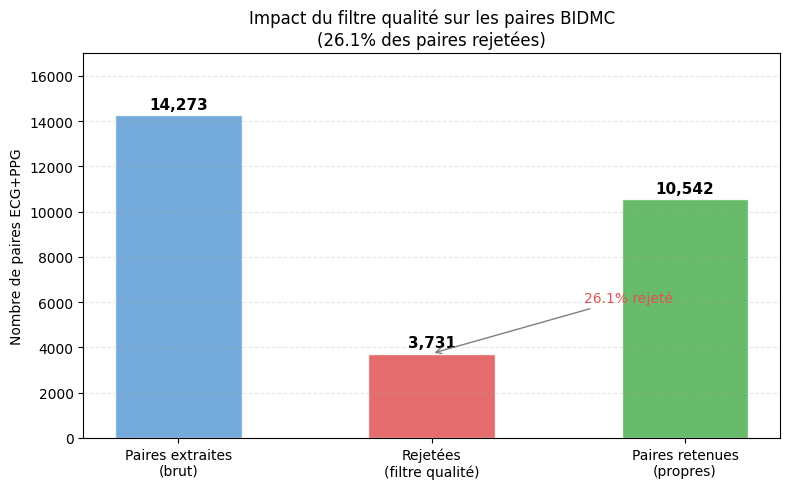

Saved.


In [11]:
import os
import matplotlib.pyplot as plt
os.makedirs('figures', exist_ok=True)

labels_bar = ['Paires extraites\n(brut)', 'Rejetées\n(filtre qualité)', 'Paires retenues\n(propres)']
values = [14273, 3731, 10542]
colors_bar = ['#5B9BD5', '#E05252', '#4CAF50']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_bar, values, color=colors_bar, alpha=0.85,
              edgecolor='white', width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Nombre de paires ECG+PPG')
ax.set_title('Impact du filtre qualité sur les paires BIDMC\n(26.1% des paires rejetées)')
ax.set_ylim(0, 17000)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.annotate('26.1% rejeté', xy=(1, 3731), xytext=(1.6, 6000),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='#E05252')
plt.tight_layout()
plt.savefig('figures/bidmc_quality_filter.png', dpi=150)
plt.show()
print("Saved.")

In [12]:
print(f"Clean beats ready: {len(ECG_clean)}")
print(f"ECG range: {ECG_clean.min():.3f} – {ECG_clean.max():.3f}")
print(f"PPG range: {PPG_clean.min():.3f} – {PPG_clean.max():.3f}")
print(f"Any NaNs in ECG: {np.isnan(ECG_clean).any()}")
print(f"Any NaNs in PPG: {np.isnan(PPG_clean).any()}")

Clean beats ready: 10542
ECG range: 0.000 – 1.000
PPG range: 0.000 – 1.000
Any NaNs in ECG: False
Any NaNs in PPG: False


In [13]:
np.save('data/ECG_pairs.npy', ECG_clean)
np.save('data/PPG_pairs.npy', PPG_clean)
print(f"Saved {len(ECG_clean)} clean paired beats")
print(f"   data/ECG_pairs.npy — {ECG_clean.nbytes/1024/1024:.1f} MB")
print(f"   data/PPG_pairs.npy — {PPG_clean.nbytes/1024/1024:.1f} MB")

Saved 10542 clean paired beats
   data/ECG_pairs.npy — 7.5 MB
   data/PPG_pairs.npy — 7.5 MB


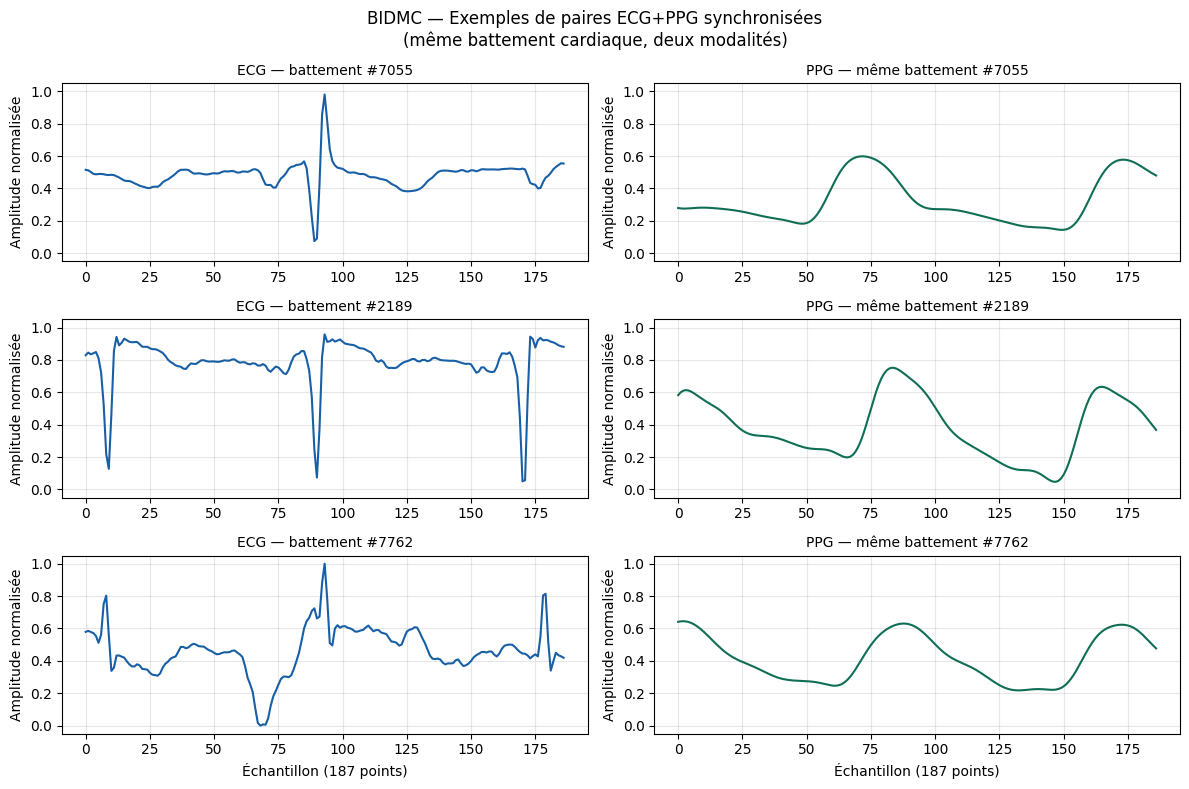

Saved.


In [14]:
import os
os.makedirs('figures', exist_ok=True)

np.random.seed(42)
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
indices = np.random.choice(len(ECG_clean), 3, replace=False)

for row, idx in enumerate(indices):
    axes[row, 0].plot(ECG_clean[idx].squeeze(), color='#185FA5', linewidth=1.5)
    axes[row, 0].set_title(f'ECG — battement #{idx}', fontsize=10)
    axes[row, 0].set_ylabel('Amplitude normalisée')
    axes[row, 0].set_ylim(-0.05, 1.05)
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(PPG_clean[idx].squeeze(), color='#0F6E56', linewidth=1.5)
    axes[row, 1].set_title(f'PPG — même battement #{idx}', fontsize=10)
    axes[row, 1].set_ylabel('Amplitude normalisée')
    axes[row, 1].set_ylim(-0.05, 1.05)
    axes[row, 1].grid(alpha=0.3)

axes[-1, 0].set_xlabel('Échantillon (187 points)')
axes[-1, 1].set_xlabel('Échantillon (187 points)')
plt.suptitle('BIDMC — Exemples de paires ECG+PPG synchronisées\n(même battement cardiaque, deux modalités)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/bidmc_paired_examples.png', dpi=150)
plt.show()
print("Saved.")

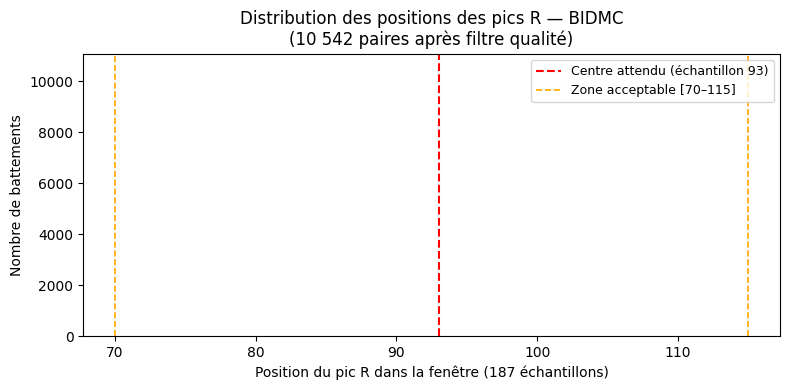

Saved.


In [17]:
peak_positions = np.array([np.argmax(ECG_clean[i].squeeze()) 
                            for i in range(len(ECG_clean))])

plt.figure(figsize=(8, 4))
plt.hist(peak_positions, bins=50, color='#185FA5', edgecolor='white')
plt.axvline(x=93, color='red', linestyle='--', linewidth=1.5, 
            label='Centre attendu (échantillon 93)')
plt.axvline(x=70, color='orange', linestyle='--', linewidth=1.2, 
            label='Zone acceptable [70–115]')
plt.axvline(x=115, color='orange', linestyle='--', linewidth=1.2)
plt.title('Distribution des positions des pics R — BIDMC\n(10 542 paires après filtre qualité)')
plt.xlabel('Position du pic R dans la fenêtre (187 échantillons)')
plt.ylabel('Nombre de battements')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/bidmc_rpeak_distribution.png', dpi=150)
plt.show()
print("Saved.")

In [15]:
import os
files = os.listdir('figures/')
for f in sorted(files):
    print(f)

bidmc_paired_examples.png
bidmc_quality_filter.png
boxplot_amplitude_classes.png
mean_waveforms.png
outliers_amplitude.png
outliers_iqr.png
smote_distribution.png
tsne_mitbih.png
